# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "halon1211"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[2.728 2.7304000000000004 2.7328 ... 2.9859999999999998 2.989 3.018] [2.728 2.7304000000000004 2.7328 ... 3.0673333333333335 3.042666666666667 3.018] [2.728 2.7304000000000004 2.7574285714285716 ... 2.964924528301887 2.991188679245283 3.018] [2.728 2.7542641509433965 2.780528301886793 ... 2.964377358490566 2.9906415094339622 3.018] [2.728 2.7304000000000004 2.7720000000000002 ... 2.9638301886792453 2.9900943396226416 3.018] [2.728 2.7304000000000004 2.7328 ... 2.9632830188679242 2.9895471698113205 3.018]] [[2.732 2.739777777777778 2.7475555555555555 ... 3.1144999999999996 3.1527499999999997 3.191] [2.732 2.739777777777778 2.7753939393939393 ... 3.0676666666666663 3.1293333333333333 3.191] [2.732 2.75369696969697 2.8064285714285715 ... 3.0820833333333333 3.147347222222222 3.191] [2.732 2.759030303030303 2.7860606060606057 ... 3.103694444444444 3.1527499999999997 3.191] [2.732 2.739777777777778 2.7571818181818184 ... 3.1144999999999996 3.15275 3.191] [2.732 2.739777777777778 2.747555555555555 ... 3.1144999999999996 3.1527499999999997 3.191]] [[2.769 2.786 2.803 ... 3.0933333333333333 3.124 3.124] [2.769 2.786 2.818157894736842 ... 3.080571428571429 3.124 3.124] [2.769 2.793578947368421 2.8408947368421056 ... 3.0805714285714285 3.124 3.124] [2.769 2.7987586206896555 2.8285172413793105 ... 3.0805714285714285 3.124 3.124] [2.769 2.786 2.8093793103448275 ... 3.0805714285714285 3.124 3.124] [2.769 2.786 2.803 ... 3.0805714285714285 3.124 3.124]] ... [[2.7105 2.714166666666667 2.717833333333333 ... 2.7499166666666666 2.7495 2.7525] [2.7105 2.714166666666667 2.715590909090909 ... 2.872 2.8122499999999997 2.7525] [2.7105 2.7130454545454548 2.7152678571428575 ... 2.748 2.750166666666667 2.7525] [2.7105 2.714595238095238 2.7186904761904764 ... 2.7473518518518523 2.75 2.7525] [2.7105 2.7141666666666664 2.718047619047619 ... 2.746703703703704 2.749833333333333 2.7525] [2.7105 2.714166666666667 2.717833333333333 ... 2.746055555555555 2.7496666666666667 2.7525]] [[2.704 2.7055000000000002 2.7070000000000003 ... 2.74425 2.73325 2.7355] [2.704 2.7055000000000002 2.7085754385964913 ... 3.0453333333333332 2.890416666666667 2.7355] [2.704 2.7062877192982455 2.710938596491228 ... 2.736 2.735472222222222 2.7355] [2.704 2.7072619047619053 2.7105238095238096 ... 2.7343703703703706 2.734916666666667 2.7355] [2.704 2.7055000000000002 2.7078809523809526 ... 2.732740740740741 2.7343611111111112 2.7355] [2.704 2.7055000000000002 2.707 ... 2.731111111111111 2.733805555555555 2.7355]] [[2.7015 2.70125 2.701 ... 2.7386666666666666 2.727 2.7329999999999997] [2.7015 2.70125 2.7036052631578946 ... 2.796 2.7645 2.7329999999999997] [2.7015 2.702552631578947 2.707513157894737 ... 2.736 2.7336666666666662 2.7329999999999997] [2.7015 2.7047499999999998 2.708 ... 2.7326944444444448 2.732 2.7329999999999997] [2.7015 2.70125 2.70275 ... 2.729388888888889 2.7303333333333333 2.7329999999999997] [2.7015 2.70125 2.701 ... 2.7260833333333334 2.7286666666666664 2.7329999999999997]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[2.728 2.7304000000000004 2.7328 ... 2.9859999999999998 2.989 3.018] [2.728 2.7304000000000004 2.7328 ... 3.0673333333333335 3.042666666666667 3.018] [2.728 2.7304000000000004 2.7574285714285716 ... 2.964924528301887 2.991188679245283 3.018] [2.728 2.7542641509433965 2.780528301886793 ... 2.964377358490566 2.9906415094339622 3.018] [2.728 2.7304000000000004 2.7720000000000002 ... 2.9638301886792453 2.9900943396226416 3.018] [2.728 2.7304000000000004 2.7328 ... 2.9632830188679242 2.9895471698113205 3.018]] [[2.732 2.739777777777778 2.7475555555555555 ... 3.1144999999999996 3.1527499999999997 3.191] [2.732 2.739777777777778 2.7753939393939393 ... 3.0676666666666663 3.1293333333333333 3.191] [2.732 2.75369696969697 2.8064285714285715 ... 3.0820833333333333 3.147347222222222 3.191] [2.732 2.759030303030303 2.7860606060606057 ... 3.103694444444444 3.1527499999999997 3.191] [2.732 2.739777777777778 2.7571818181818184 ... 3.1144999999999996 3.15275 3.191] [2.732 2.739777777777778 2.747555555555555 ... 3.1144999999999996 3.1527499999999997 3.191]] [[2.769 2.786 2.803 ... 3.0933333333333333 3.124 3.124] [2.769 2.786 2.818157894736842 ... 3.080571428571429 3.124 3.124] [2.769 2.793578947368421 2.8408947368421056 ... 3.0805714285714285 3.124 3.124] [2.769 2.7987586206896555 2.8285172413793105 ... 3.0805714285714285 3.124 3.124] [2.769 2.786 2.8093793103448275 ... 3.0805714285714285 3.124 3.124] [2.769 2.786 2.803 ... 3.0805714285714285 3.124 3.124]] ... [[2.7105 2.714166666666667 2.717833333333333 ... 2.7499166666666666 2.7495 2.7525] [2.7105 2.714166666666667 2.715590909090909 ... 2.872 2.8122499999999997 2.7525] [2.7105 2.7130454545454548 2.7152678571428575 ... 2.748 2.750166666666667 2.7525] [2.7105 2.714595238095238 2.7186904761904764 ... 2.7473518518518523 2.75 2.7525] [2.7105 2.7141666666666664 2.718047619047619 ... 2.746703703703704 2.749833333333333 2.7525] [2.7105 2.714166666666667 2.717833333333333 ... 2.746055555555555 2.7496666666666667 2.7525]] [[2.704 2.7055000000000002 2.7070000000000003 ... 2.74425 2.73325 2.7355] [2.704 2.7055000000000002 2.7085754385964913 ... 3.0453333333333332 2.890416666666667 2.7355] [2.704 2.7062877192982455 2.710938596491228 ... 2.736 2.735472222222222 2.7355] [2.704 2.7072619047619053 2.7105238095238096 ... 2.7343703703703706 2.734916666666667 2.7355] [2.704 2.7055000000000002 2.7078809523809526 ... 2.732740740740741 2.7343611111111112 2.7355] [2.704 2.7055000000000002 2.707 ... 2.731111111111111 2.733805555555555 2.7355]] [[2.7015 2.70125 2.701 ... 2.7386666666666666 2.727 2.7329999999999997] [2.7015 2.70125 2.7036052631578946 ... 2.796 2.7645 2.7329999999999997] [2.7015 2.702552631578947 2.707513157894737 ... 2.736 2.7336666666666662 2.7329999999999997] [2.7015 2.7047499999999998 2.708 ... 2.7326944444444448 2.732 2.7329999999999997] [2.7015 2.70125 2.70275 ... 2.729388888888889 2.7303333333333333 2.7329999999999997] [2.7015 2.70125 2.701 ... 2.7260833333333334 2.7286666666666664 2.7329999999999997]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'halon1211' (lon: 6, lat: 12, year: 26, month: 12)> Size: 180kB
<Quantity([[[[3.591      3.6815     3.668      ... 3.802      3.725
    3.782     ]
   [3.748      3.78       3.7645     ... 3.899      3.8695
    3.901     ]
   [3.8885     3.904      3.8995     ... 3.998      4.01233333
    3.984     ]
   ...
   [3.02566667 3.00875    3.00566667 ... 2.975      2.96766667
    2.95466667]
   [2.9415     2.92325    2.91566667 ... 2.88975    2.875
    2.87225   ]
   [2.8605     2.851      2.8455     ... 2.81       2.802
    2.787     ]]

  [[3.591      3.64965    3.6311625  ... 3.77279167 3.7478
    3.742225  ]
   [3.775375   3.7319     3.788725   ... 3.91225    3.88923333
    3.904025  ]
   [3.905875   3.91285    3.893925   ... 4.035375   4.01258333
    4.0094    ]
...
   [3.14591667 3.14658333 3.14236667 ... 3.05316667 3.06328333
    3.06225   ]
   [3.05958333 3.06033333 3.04905    ... 2.96244444 2.969
    2.96378333]
   [2.95393333 2.9545     2.94627778 ... 2.86718889 2.86738889
    2.86816667]]

  [[4.0875     4.027      4.091      ... 4.049      4.12733333
    4.10866667]
   [4.162      4.156      4.17166667 ... 4.12666667 4.253
    4.222     ]
   [4.26825    4.24033333 4.28633333 ... 4.26975    4.3065
    4.3045    ]
   ...
   [3.17283333 3.17025    3.165      ... 3.079125   3.082625
    3.0864    ]
   [3.070875   3.068      3.0608     ... 2.982625   2.98183333
    2.9775    ]
   [2.97175    2.97       2.96783333 ... 2.87516667 2.8732
    2.883     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 208B 1998 1999 2000 2001 2002 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[3.591 3.6815 3.668 ... 2.81 2.8019999999999996 2.787] [3.591 3.6496500000000003 3.6311625 ... 2.815925 2.8026999999999997 2.792266666666667] [3.629 3.6422499999999998 3.6413125 ... 2.830625 2.8175 2.8073333333333337] ... [4.043277777777778 4.01325 4.018000000000001 ... 2.86585 2.8609999999999998 2.8601] [4.0555 4.027 4.014 ... 2.8382 2.838 2.8385] [4.0875 4.027 4.091 ... 2.85875 2.8528000000000002 2.865]] [[3.591 3.6815 3.668 ... 2.81 2.8019999999999996 2.787] [3.591 3.6415 3.6154999999999995 ... 2.8129999999999997 2.798 2.789] [3.6952142857142856 3.6954285714285717 3.6673571428571425 ... 2.8201071428571427 2.8049107142857146 2.8008214285714286] ... [3.982 4.038 4.016 ... 2.9245 2.8975 3.1145] [4.034750000000001 4.027 4.0535 ... 2.883416666666667 2.8649500000000003 2.98075] [4.0875 4.027 4.091 ... 2.842333333333334 2.8324000000000003 2.847]] [[3.591 3.6815 3.6679999999999997 ... 2.81 2.8019999999999996 2.787] [3.591 3.688464285714286 3.6676785714285716 ... 2.8153382352941176 2.804661764705882 2.7988181818181816] [3.6621071428571432 3.7423928571428573 3.719535714285714 ... 2.8230147058823527 2.813985294117647 2.8204545454545458] ... [3.982375 4.024441176470589 3.9850312500000005 ... 2.8767500000000004 2.87925 2.841] [4.037222222222222 4.027 4.035347222222223 ... 2.8405 2.8445 2.845] [4.0875 4.027 4.091 ... 2.875166666666667 2.8732 2.883]] [[3.591 3.6815 3.668 ... 2.81 2.8019999999999996 2.787] [3.591 3.708 3.6961477272727272 ... 2.826375 2.8193749999999995 2.8059375] [3.629 3.7344999999999997 3.7242954545454543 ... 2.8427499999999997 2.8367499999999994 2.824875] ... [3.9869444444444446 4.010882352941176 3.979694444444444 ... 2.9423333333333335 2.938333333333334 2.936] [4.041791666666667 4.027 4.030010416666666 ... 2.9251666666666667 2.926166666666667 2.9275] [4.0875 4.027 4.091 ... 2.908 2.914 2.919]] [[3.591 3.6815 3.6679999999999997 ... 2.81 2.8019999999999996 2.787] [3.591 3.66595 3.6624875 ... 2.821775 2.8120999999999996 2.7988] [3.629 3.6755 3.681636363636364 ... 2.8373125000000003 2.8281875 2.8158020833333333] ... [3.9915138888888895 3.997323529411765 3.974357638888889 ... 2.9168388888888885 2.9125555555555556 2.9107] [4.0463611111111115 4.027 4.024673611111111 ... 2.896177777777778 2.8967777777777783 2.8978333333333333] [4.0875 4.027 4.091 ... 2.891583333333333 2.8936 2.901]] [[3.591 3.6815 3.668 ... 2.81 2.8019999999999996 2.787] [3.591 3.6578000000000004 3.6468250000000006 ... 2.81885 2.8074 2.7955333333333336] [3.629 3.6504 3.656975 ... 2.83355 2.8222 2.8106] ... [3.9960833333333334 3.983764705882353 3.9690208333333334 ... 2.8913444444444445 2.886777777777778 2.8854] [4.0509305555555555 4.027 4.019336805555556 ... 2.867188888888889 2.8673888888888888 2.8681666666666668] [4.0875 4.027 4.091 ... 2.875166666666667 2.8732 2.883]]]
Units,ppt


### Longitudinal-mean

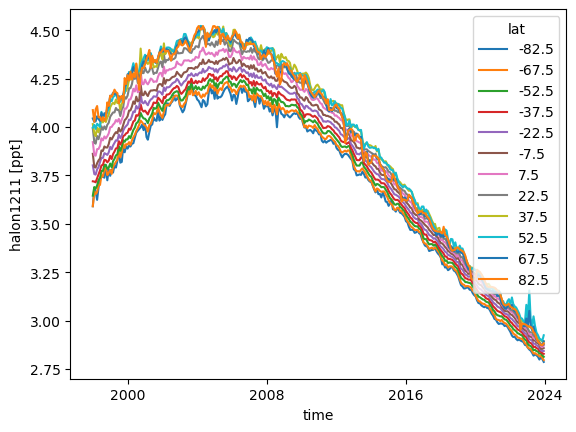

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

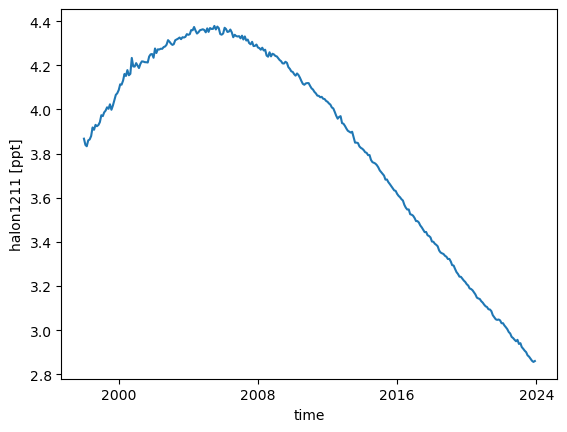

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

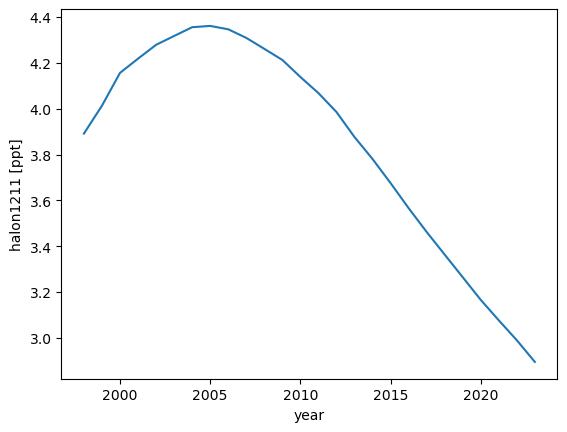

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 4kB
Dimensions:               (lat: 12, eof: 12, year: 26)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 208B 1998 1999 2000 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.4774 ... -0.05329
    principal-components  (year, eof) float64 2kB [] -0.4491 ... 1.266e-16

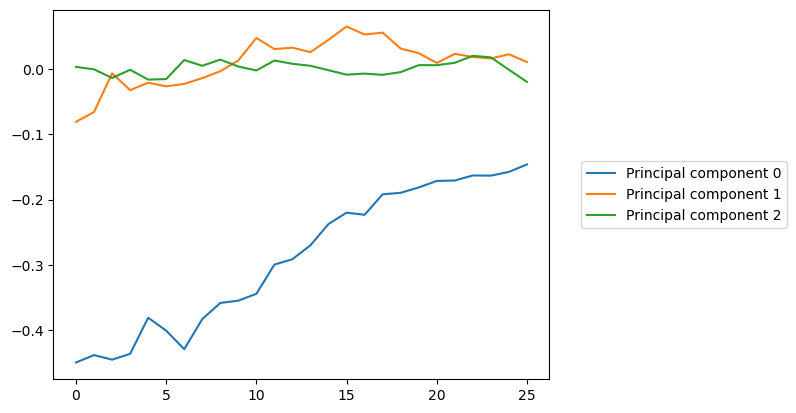

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

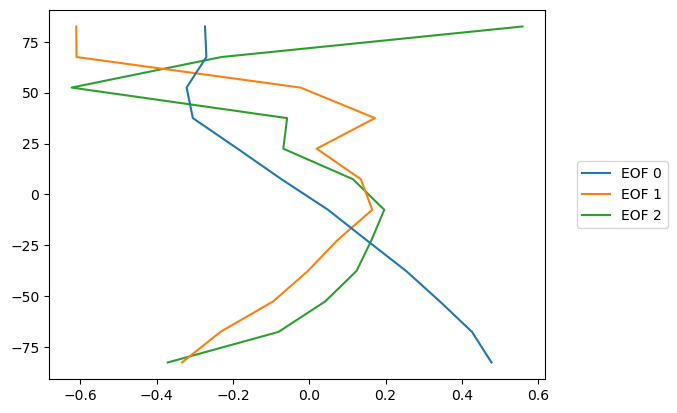

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

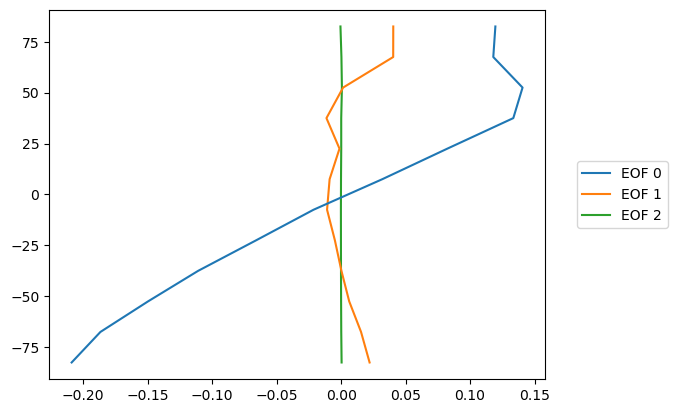

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.47735680541477105] [0.42636091216110183] [0.34204207568182743] [0.25328148441367876] [0.15056103856967723] [0.04895164172839968] [-0.07286398436010212] [-0.1880266080398935] [-0.3049433511262583] [-0.32131133255487104] [-0.26947822900927465] [-0.27317498087609043]]
Units,ppt
Magnitude,[[-0.44909409031579517] [-0.4378065619457543] [-0.4447578950872114] [-0.4359311426575614] [-0.38065686674656735] [-0.40044474437385963] [-0.42876602894283505] [-0.38279990575108463] [-0.35804707138433006] [-0.35457836555904304] [-0.34412165340996503] [-0.2994502963122068] [-0.2912536214728673] [-0.26987466788303516] [-0.2373851328002721] [-0.2200870459610971] [-0.22333236230417441] [-0.19202207615940048] [-0.18971249220959352] [-0.18153352835071188] [-0.17161537169264396] [-0.1709213191637085] [-0.16320296954748542] [-0.16348313181083327] [-0.15777686655343207] [-0.14635433946311588]]
Units,dimensionless


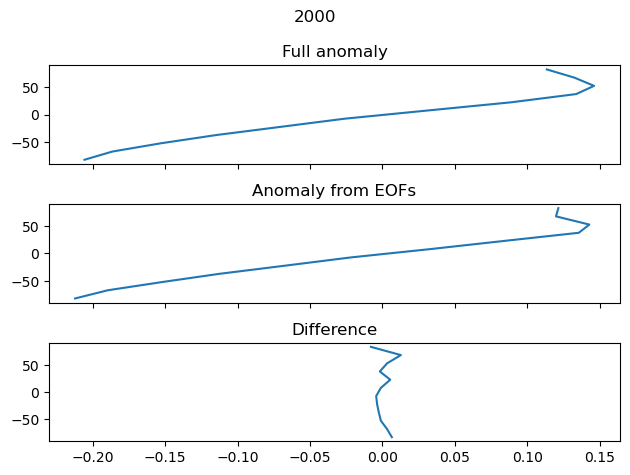

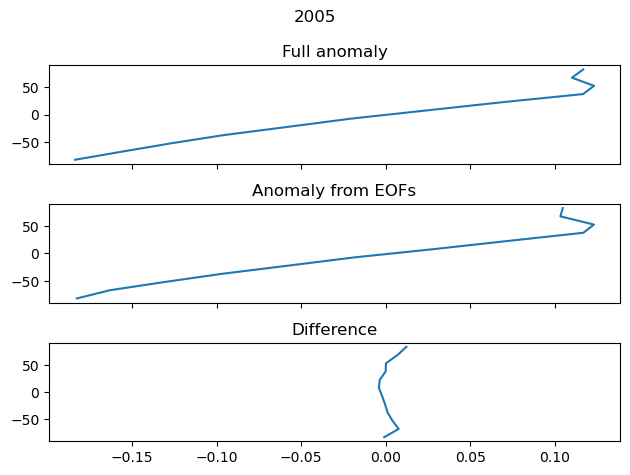

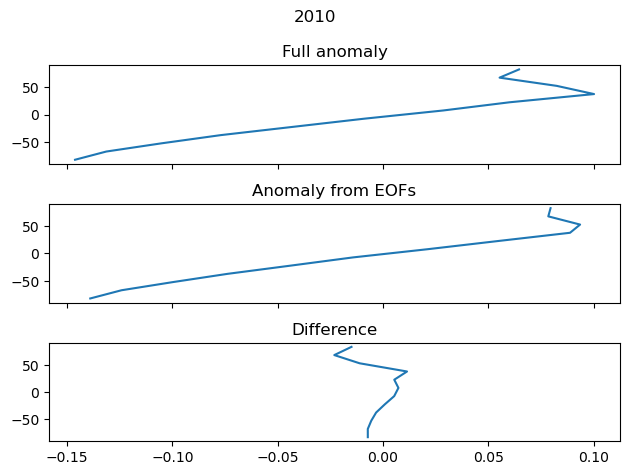

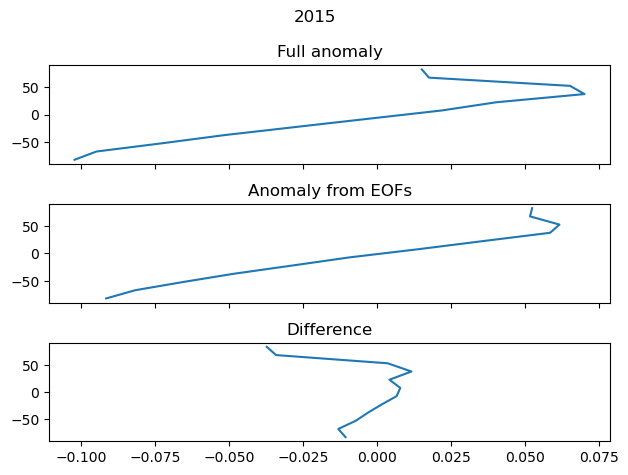

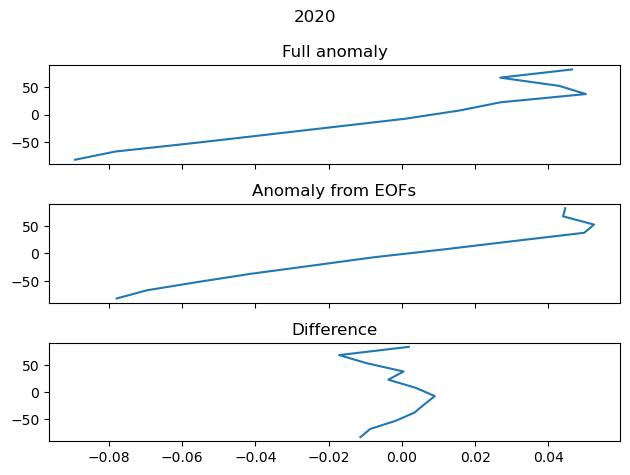

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 16054.36it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 19223.82it/s]

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 20135.45it/s]

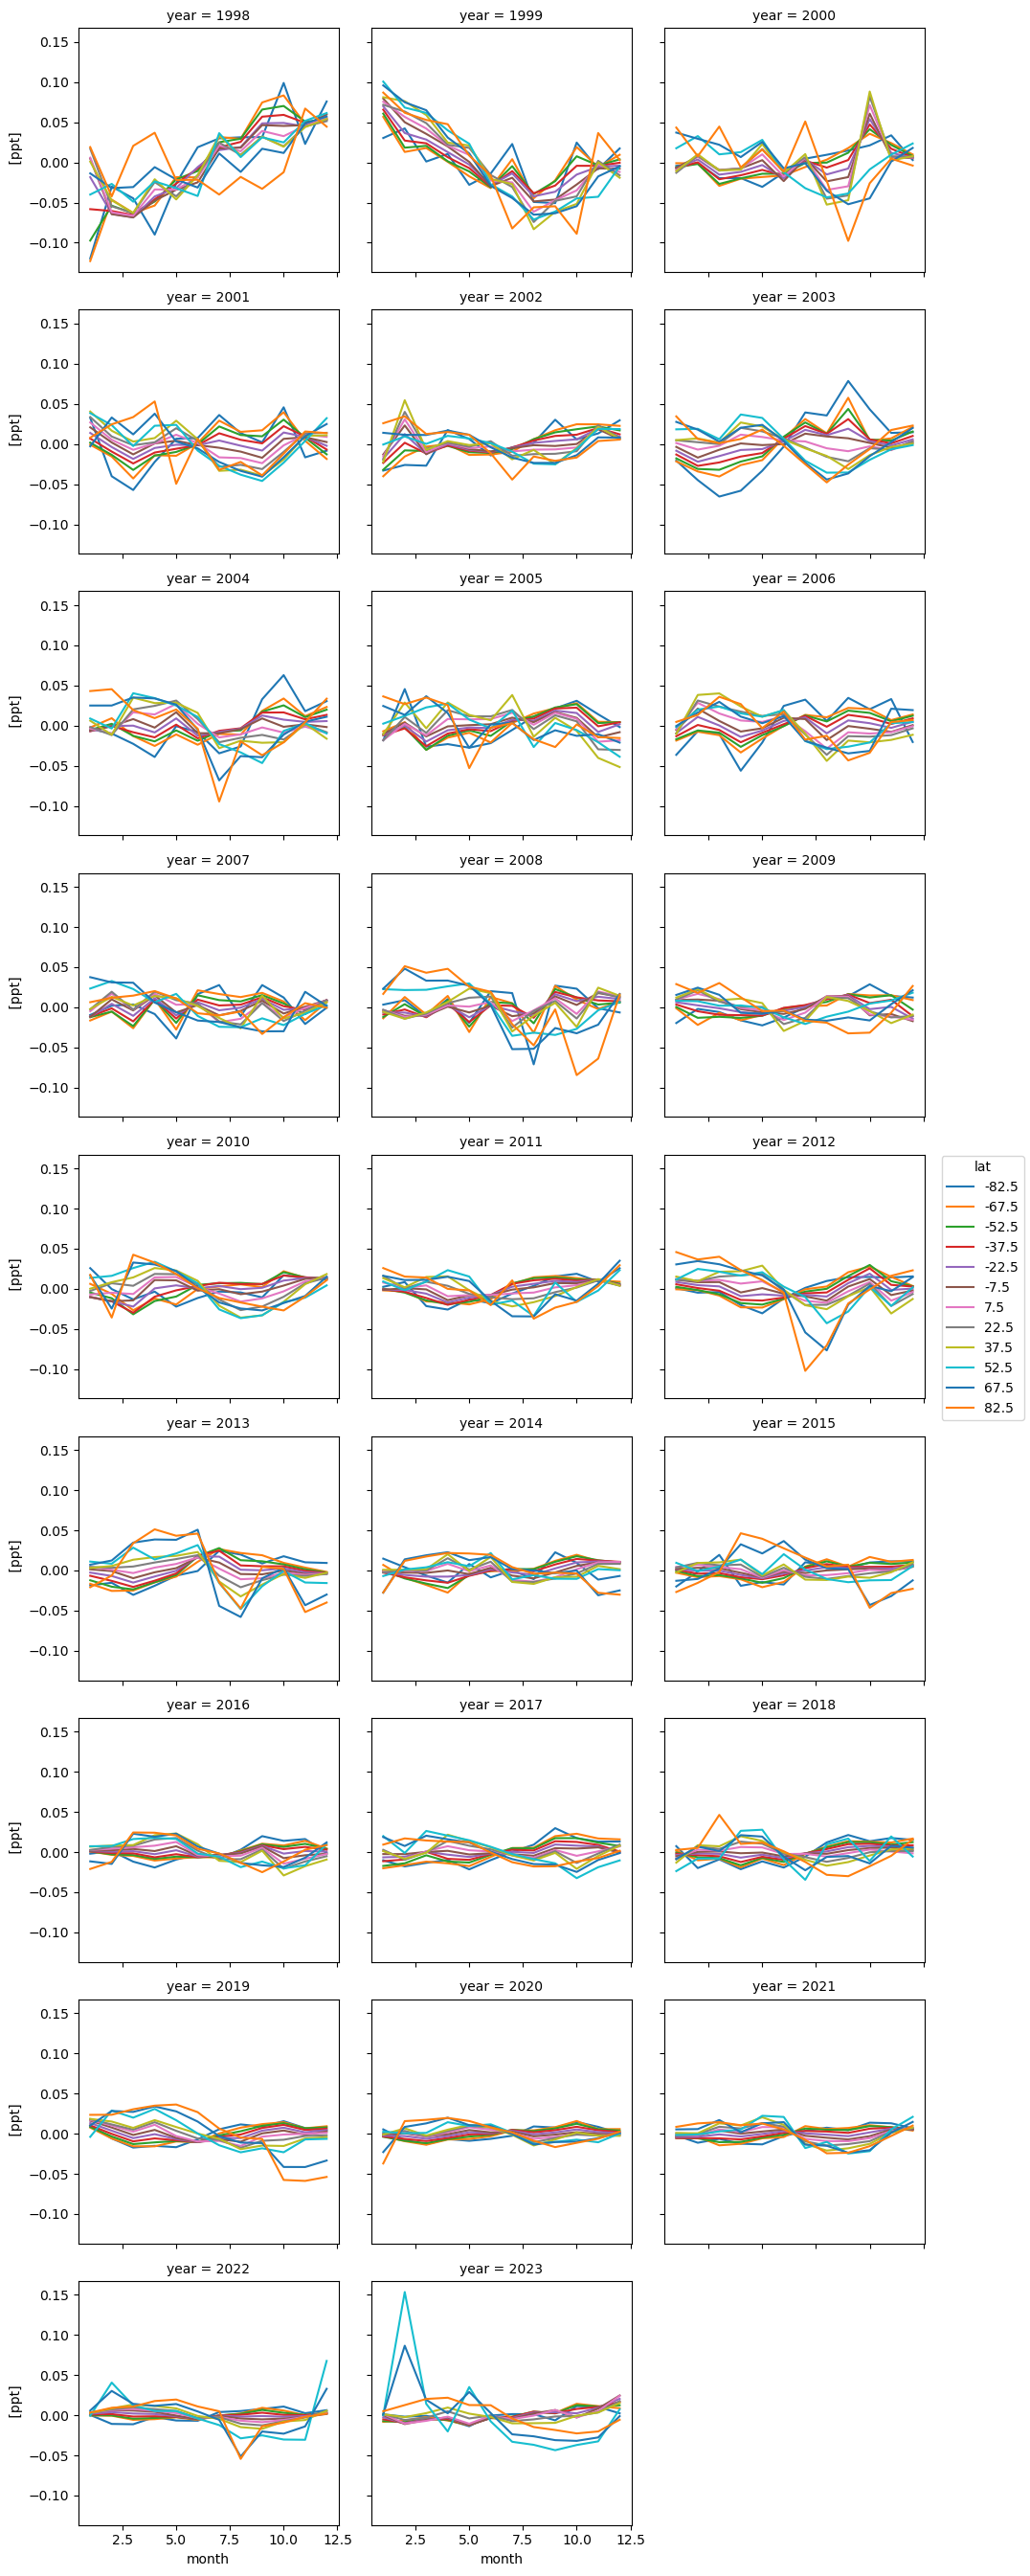

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

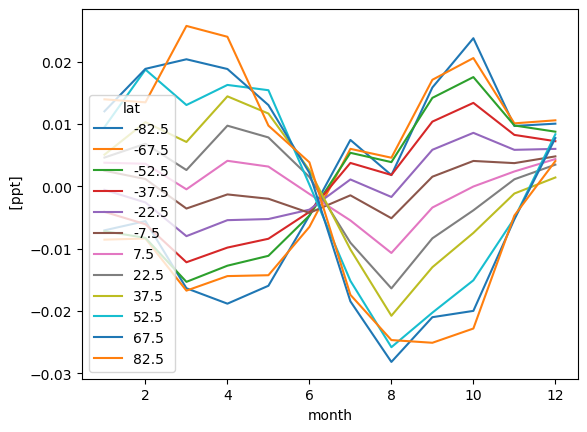

In [22]:
seasonality.plot.line(hue="lat")

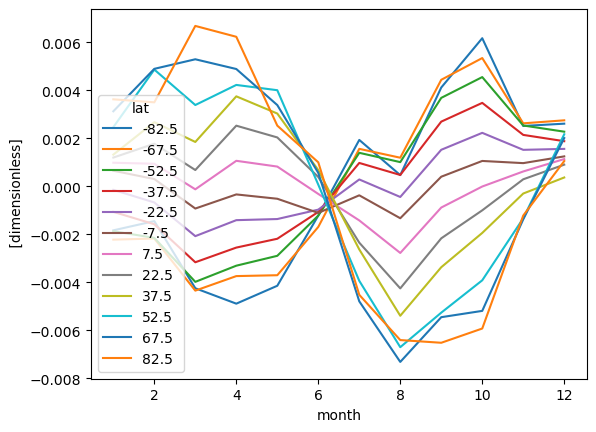

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[3.8914416393152464 4.013144560485334 4.156135283114349 4.218164592508457 4.278421828523327 4.31701535412911 4.355243928008673 4.360824228828833 4.346103014677363 4.308645572745664 4.260863359677518 4.212457110902462 4.138190330247491 4.067998574158029 3.985427424861799 3.876324744242828 3.780487343404955 3.6755315952132963 3.5662664427013886 3.462432107382194 3.363558506469653 3.2650664904829907 3.1662098312627815 3.0769647654558008 2.9901187001989062 2.8955490873420353]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.47735680541477105] [0.42636091216110183] [0.34204207568182743] [0.25328148441367876] [0.15056103856967723] [0.04895164172839968] [-0.07286398436010212] [-0.1880266080398935] [-0.3049433511262583] [-0.32131133255487104] [-0.26947822900927465] [-0.27317498087609043]]
Units,ppt
Magnitude,[[-0.44909409031579517] [-0.4378065619457543] [-0.4447578950872114] [-0.4359311426575614] [-0.38065686674656735] [-0.40044474437385963] [-0.42876602894283505] [-0.38279990575108463] [-0.35804707138433006] [-0.35457836555904304] [-0.34412165340996503] [-0.2994502963122068] [-0.2912536214728673] [-0.26987466788303516] [-0.2373851328002721] [-0.2200870459610971] [-0.22333236230417441] [-0.19202207615940048] [-0.18971249220959352] [-0.18153352835071188] [-0.17161537169264396] [-0.1709213191637085] [-0.16320296954748542] [-0.16348313181083327] [-0.15777686655343207] [-0.14635433946311588]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.0018371924398776984 -0.0014521172116673156 -0.00425022827915891 -0.004892583980356302 -0.004146570066125419 -0.0012214447071294042 0.0019306794541562925 0.00046405034025873165 0.004115352851959913 0.006169456098624368 0.002512511426176495 0.002608096364366686] [-0.0022240466614106102 -0.002178465834153173 -0.004349271082263129 -0.003743501932238411 -0.003707498625568383 -0.0016944620620141842 0.0015589355587723758 0.0011892688789958065 0.004436905309862865 0.005342315885237966 0.002622073215970955 0.0027477585311930686] [-0.001872908800427693 -0.0021515246072755056 -0.003983706829837305 -0.003310182659068877 -0.002898386718647164 -0.0012224446398106797 0.0013938337884703922 0.0010055392551462704 0.003683590494129127 0.004549329239211563 0.002532546956500379 0.0022743265089277226] [-0.0010663001913762396 -0.0015825115251288774 -0.0031670737933240894 -0.002555694288230333 -0.0021877256331234926 -0.0010689077218683015 0.0009717192460348389 0.00047074634695867796 0.0026933223553255296 0.0034743760685604554 0.0021400590678700188 0.0018780031232971976] [-0.00015019734487153503 -0.0006749636027438245 -0.002078734254965149 -0.001412919681718123 -0.001366267487449404 -0.0009743618460972937 0.0002831694918599742 -0.0004466162441046698 0.001519890193718879 0.0022258844563628113 0.0015176753923497636 0.0015574550212027825] [0.0006470732528760169 0.0003005006817491645 -0.0009282921247432216 -0.00034014403843877664 -0.0005205281708435141 -0.0011098033394708491 -0.00037753580824494636 -0.0013328671894232021 0.00039814980973371995 0.001054640728088566 0.0009638013250168732 0.0012450200773315532] [0.0009799309788996958 0.0009379312883069767 -0.00012728830931024198 0.0010604680665036311 0.0008203829853651045 -0.00032067536595823217 -0.001423765823321179 -0.002779684707904835 -0.0008870410053009736 -1.0557331310959803e-05 0.0006167125009433585 0.001133601389397274] [0.0011956760810148824 0.0017720356694830002 0.0006765223663610969 0.0025245801080752196 0.002034334534011048 0.0003864619262129044 -0.0023508484297355015 -0.00425579336706749 -0.002169746397725133 -0.0010034480022984094 0.00029011131298035573 0.0009001277354057761] [0.0013165653647605412 0.0026716785630150806 0.0018459493428053528 0.0037470479117430065 0.0030303864766147433 0.0006740136482787097 -0.002633114448106702 -0.005396257192267819 -0.0033735635734852714 -0.0019448065846734979 -0.0003032902031849217 0.00036540468359328663] [0.0024625747187560156 0.004861933716553068 0.003385490208608915 0.004222353006963715 0.004002543537428028 6.635950626913478e-05 -0.003940631557388801 -0.006706056787115141 -0.00526701192502122 -0.003919108736110425 -0.0013349377512431048 0.002166506326242607] [0.0031235044037445964 0.004892963359741477 0.005291521165363897 0.00488599296220477 0.0033832207653667996 0.0005577335563591894 -0.004795151651338891 -0.007320234400488584 -0.005455994807155406 -0.005193340343944071 -0.0013784017689096669 0.002008196261093691] [0.003623009125907301 0.0034975214635349764 0.006681509292609712 0.00622894865203855 0.0025268333705098004 0.0009974371671944145 -0.004524044449065231 -0.006409397169104602 -0.0065221382851899014 -0.0059286073770590045 -0.0012209939912053715 0.001049930095255258]]
Units,dimensionless
